In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm
import colorcet as ccm

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33214 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:33214/status,
Dashboard: http://127.0.0.1:33214/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36902,Workers: 0
Dashboard: http://127.0.0.1:33214/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41965,Total threads: 6
Dashboard: http://127.0.0.1:35614/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:38281,


In [4]:
from xmitgcm import open_mdsdataset

In [5]:
from utils import *

In [6]:
# input_data = "/data/hpcdata/users/josnez/MITgcm/verification/ISOBLJ_channel/"
# input_data="/data/oceans_output/shelf/josnez/MITgcm/ISOBLJ/ISOBLJ/"
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [7]:
data = dict(dz8={"PATH":"run_z512_dz8/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

ISOBLJ = ISOBLJ_Struct(input_data,data=data)

In [8]:
ISOBLJ.open_datasets(prefix=['MOM_tend'])

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [9]:
Um_Diss = shifted_dataset(ISOBLJ.get_variable("Um_Diss"),method = "du")
Vm_Diss = shifted_dataset(ISOBLJ.get_variable("Vm_Diss"),method = "du")

# Um_ImplD = shifted_dataset(ISOBLJ.get_variable("Um_ImplD"),method = "du")
# Vm_ImplD = shifted_dataset(ISOBLJ.get_variable("Vm_ImplD"),method = "du")

Um_Advec = shifted_dataset(ISOBLJ.get_variable("Um_Advec"),method = "du")
Vm_Advec = shifted_dataset(ISOBLJ.get_variable("Vm_Advec"),method = "du")

Um_Cori = shifted_dataset(ISOBLJ.get_variable("Um_Cori"),method = "du")
Vm_Cori = shifted_dataset(ISOBLJ.get_variable("Vm_Cori"),method = "du")

Um_dPhiX = shifted_dataset(ISOBLJ.get_variable("Um_dPhiX"),method = "du")
Vm_dPhiY = shifted_dataset(ISOBLJ.get_variable("Vm_dPhiY"),method = "du")

TOTUTEND = shifted_dataset(ISOBLJ.get_variable("TOTUTEND"),method = "du")
TOTVTEND = shifted_dataset(ISOBLJ.get_variable("TOTVTEND"),method = "du")

c80m_Td2_vshift16_ryan_dz4 does not have var Um_Diss
c80m_Td2_vshift16_ryan_dz4 does not have var Vm_Diss
c80m_Td2_vshift16_ryan_dz4 does not have var Um_Advec
c80m_Td2_vshift16_ryan_dz4 does not have var Vm_Advec
c80m_Td2_vshift16_ryan_dz4 does not have var Um_Cori
c80m_Td2_vshift16_ryan_dz4 does not have var Vm_Cori
c80m_Td2_vshift16_ryan_dz4 does not have var Um_dPhiX
c80m_Td2_vshift16_ryan_dz4 does not have var Vm_dPhiY
c80m_Td2_vshift16_ryan_dz4 does not have var TOTUTEND
c80m_Td2_vshift16_ryan_dz4 does not have var TOTVTEND


In [10]:
def coord_dtype(ds):
    for coord in ds.coords:
        ds[coord]= ds[coord].astype(np.float64)
    return ds
    
def VAR_withBL_TopZ(ds,hfacc=None,hfacc_var="hFacC",var='THETA',out_name="Tf"):
    ds_return=[]
    if not hfacc:
        hfacc=ds
    for dvar in ds.data_vars:
        # print(dvar)
        data = ds.reset_coords(drop=True)[dvar]
        dz = int(dvar.split("dz")[-1])
        z_coord = "Z_dz{0}".format(dz)
        hfacc_name = dvar.replace(var,hfacc_var)
        #This only works for a constant dz
        drK0 = hfacc[hfacc_name].isel({z_coord:0}) * dz
        drK1 = (1 - hfacc[hfacc_name].isel({z_coord:0})) * dz
        recip_drLoc = 1 / ( drK0 + drK1 )

        tvar = (data.isel({z_coord:0}) * drK0 
              + data.isel({z_coord:1}) * drK1)#.compute()

        weighted_var = tvar*recip_drLoc
        ds_return.append(weighted_var.rename(dvar.replace(var,out_name)))
        # break
        
    return xr.merge(ds_return)

def interp_vels_uStarTopDz(Uvel,Vvel,var1="UVEL"):    
    grids = ISOBLJ._get_grid()

    U_shift = coord_dtype(shifted_dataset(Uvel,method = "ud").astype(float))
    V_shift = coord_dtype(shifted_dataset(Vvel,method = "ud").astype(float))

    hfacc_U = shift_hfacc(U_shift)
    hfacc_V = shift_hfacc(V_shift)

    U_top = VAR_withBL_TopZ(U_shift,hfacc_U,hfacc_var="hFacW",var="UVEL",out_name="UVEL")
    V_top = VAR_withBL_TopZ(V_shift,hfacc_V,hfacc_var="hFacS",var="VVEL",out_name="VVEL")

    Uvel_interp =  (0.5 * (U_top + U_top.roll(XG = 1))).rename({"XG":"XC"})
    Vvel_interp =  (0.5 * (V_top + V_top.roll(YG = 1))).rename({"YG":"YC"})
    Uvel_interp["XC"] = Vvel_interp["XC"]
    Vvel_interp["YC"] = Uvel_interp["YC"]
    return Uvel_interp, Vvel_interp
    # return U_top, V_top

def shift_hfacc(ds):
    hfacc_ds=[]
    for var in ds.data_vars:
        zcoord = "Z_dz{0}".format(var.split("dz")[-1])
        hfacc_var = [coord for coord in ds[var].coords if "hFac" in coord ][0]
        hfacc_name = hfacc_var.split("_")[0]
        var_name = var.split("_")[0]
        new_name = var.replace(var_name, hfacc_name)
        data = ds.reset_coords()[var.replace(var_name, hfacc_name)]
        hfacc_shifted = shifted_computations(data, method="ud",dims=[zcoord] )
        hfacc_ds.append(hfacc_shifted)
    return xr.merge(hfacc_ds)
    

In [11]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"
data = dict(dz8={"PATH":"run_z512_dz8/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

ISOBLJ_vels = ISOBLJ_Struct(input_data,data=data)

In [12]:
ISOBLJ_vels.open_datasets(prefix=['state2D','scalars','vels'])

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [13]:
Uvel = ISOBLJ_vels.get_variable("UVEL")
Vvel = ISOBLJ_vels.get_variable("VVEL")
SHIuStar = ISOBLJ_vels.get_variable("SHIuStar")
# ISOBLJ_vels.data
RHOAnoma = ISOBLJ_vels.get_variable("RHOAnoma")

In [14]:
SHIuBdly = ISOBLJ_vels.get_variable("SHIuBdly")
SHIvBdly = ISOBLJ_vels.get_variable("SHIvBdly")

c80m_Td2_vshift16_ryan_dz4 does not have var SHIuBdly
c80m_Td2_vshift16_ryan_dz4 does not have var SHIvBdly


In [15]:
rhoAnom = shifted_dataset(RHOAnoma,method = "du")
rhoA = rhoAnom.mean("XC")

In [16]:
U = SHIuBdly 

V = SHIvBdly

In [17]:
ustar_return=[]
Cd = 0.0097
for dvar in SHIuBdly.data_vars:
    velSq = SHIuBdly[dvar]**2 + SHIvBdly[dvar.replace("SHIuBdly","SHIvBdly")]**2
    velSq = velSq.where(velSq > 1e-6, 1e-6)
    Ustar_2 = velSq * Cd
    ustar_return.append(Ustar_2.rename(dvar.replace("SHIuBdly","MAGVEL")))

Ustar2 = xr.merge(ustar_return)
    

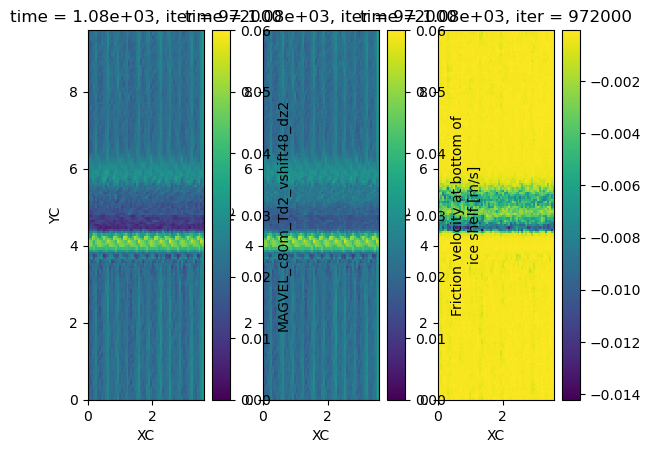

In [18]:
fig, ax = plt.subplots(1,3)
np.sqrt(Ustar2.MAGVEL_c80m_Td2_vshift48_dz2).isel(time=-1).plot(ax=ax[0],vmin=0,vmax=0.06)
SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2.isel(time=-1).plot(ax=ax[1],vmin=0,vmax=0.06)
(np.sqrt(Ustar2.MAGVEL_c80m_Td2_vshift48_dz2) - SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2).isel(time=-1).plot(ax=ax[2])

In [19]:
from matplotlib.collections import PolyCollection
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

def plot_hfacc_surf_shifted(ax,ds,dz,z_shift=512):
    
    x_ = (ds.YC - 60/2000)
    x_ = np.append(np.roll(np.repeat(x_, 2),-1)[:-1], x_[-1]+60/2000)
    Hfacc_shifted = shifted_computations(ds.hFacC,method="du").mean("XC").T

    z_ = (abs(((np.sum( 1 - Hfacc_shifted ,axis=0))  * dz) + z_shift) + z_shift) + dz
    z_ = np.repeat(z_, 2) 

    x = np.append(np.hstack((0 ,x_)),x_[-1]+120/2000)
    if z_shift==-512:
        z = np.append(np.hstack((0 ,z_)),0)
    else:
        z = np.append(np.hstack((z_shift ,z_)),z_shift)

    verts = [np.array(list(zip(x, z)))]
    # print(verts)
    
    poly = PolyCollection(verts, alpha=1, zorder=1,
                          facecolors=[[0.9, 0.9, 0.9]])
    ax.add_collection(poly)

def plot_channel_surface_property(ax,z,ds,dz,freq=1,**kwargs):
    top = ds.dropna("time").isel(time=-1).mean("XC")
    x = ds.YC[::freq] - 60/2000
    cbar = ax.scatter(x, z, c=top,**kwargs)
    return cbar

def extract_channel_coords(ds,dz,shift=0,freq=1):
    z =((np.max(np.cumsum( abs(ds.hFacC.isel(XG=0) -1 ),axis=0),axis=0) * -dz) + 512 + shift )[::freq]
    return z

In [20]:
z = extract_channel_coords(Um_Advec["hFacW_c80m_Td2_vshift24_dz4"].rename({"hFacW_c80m_Td2_vshift24_dz4":"hFacC"}),dz=4)

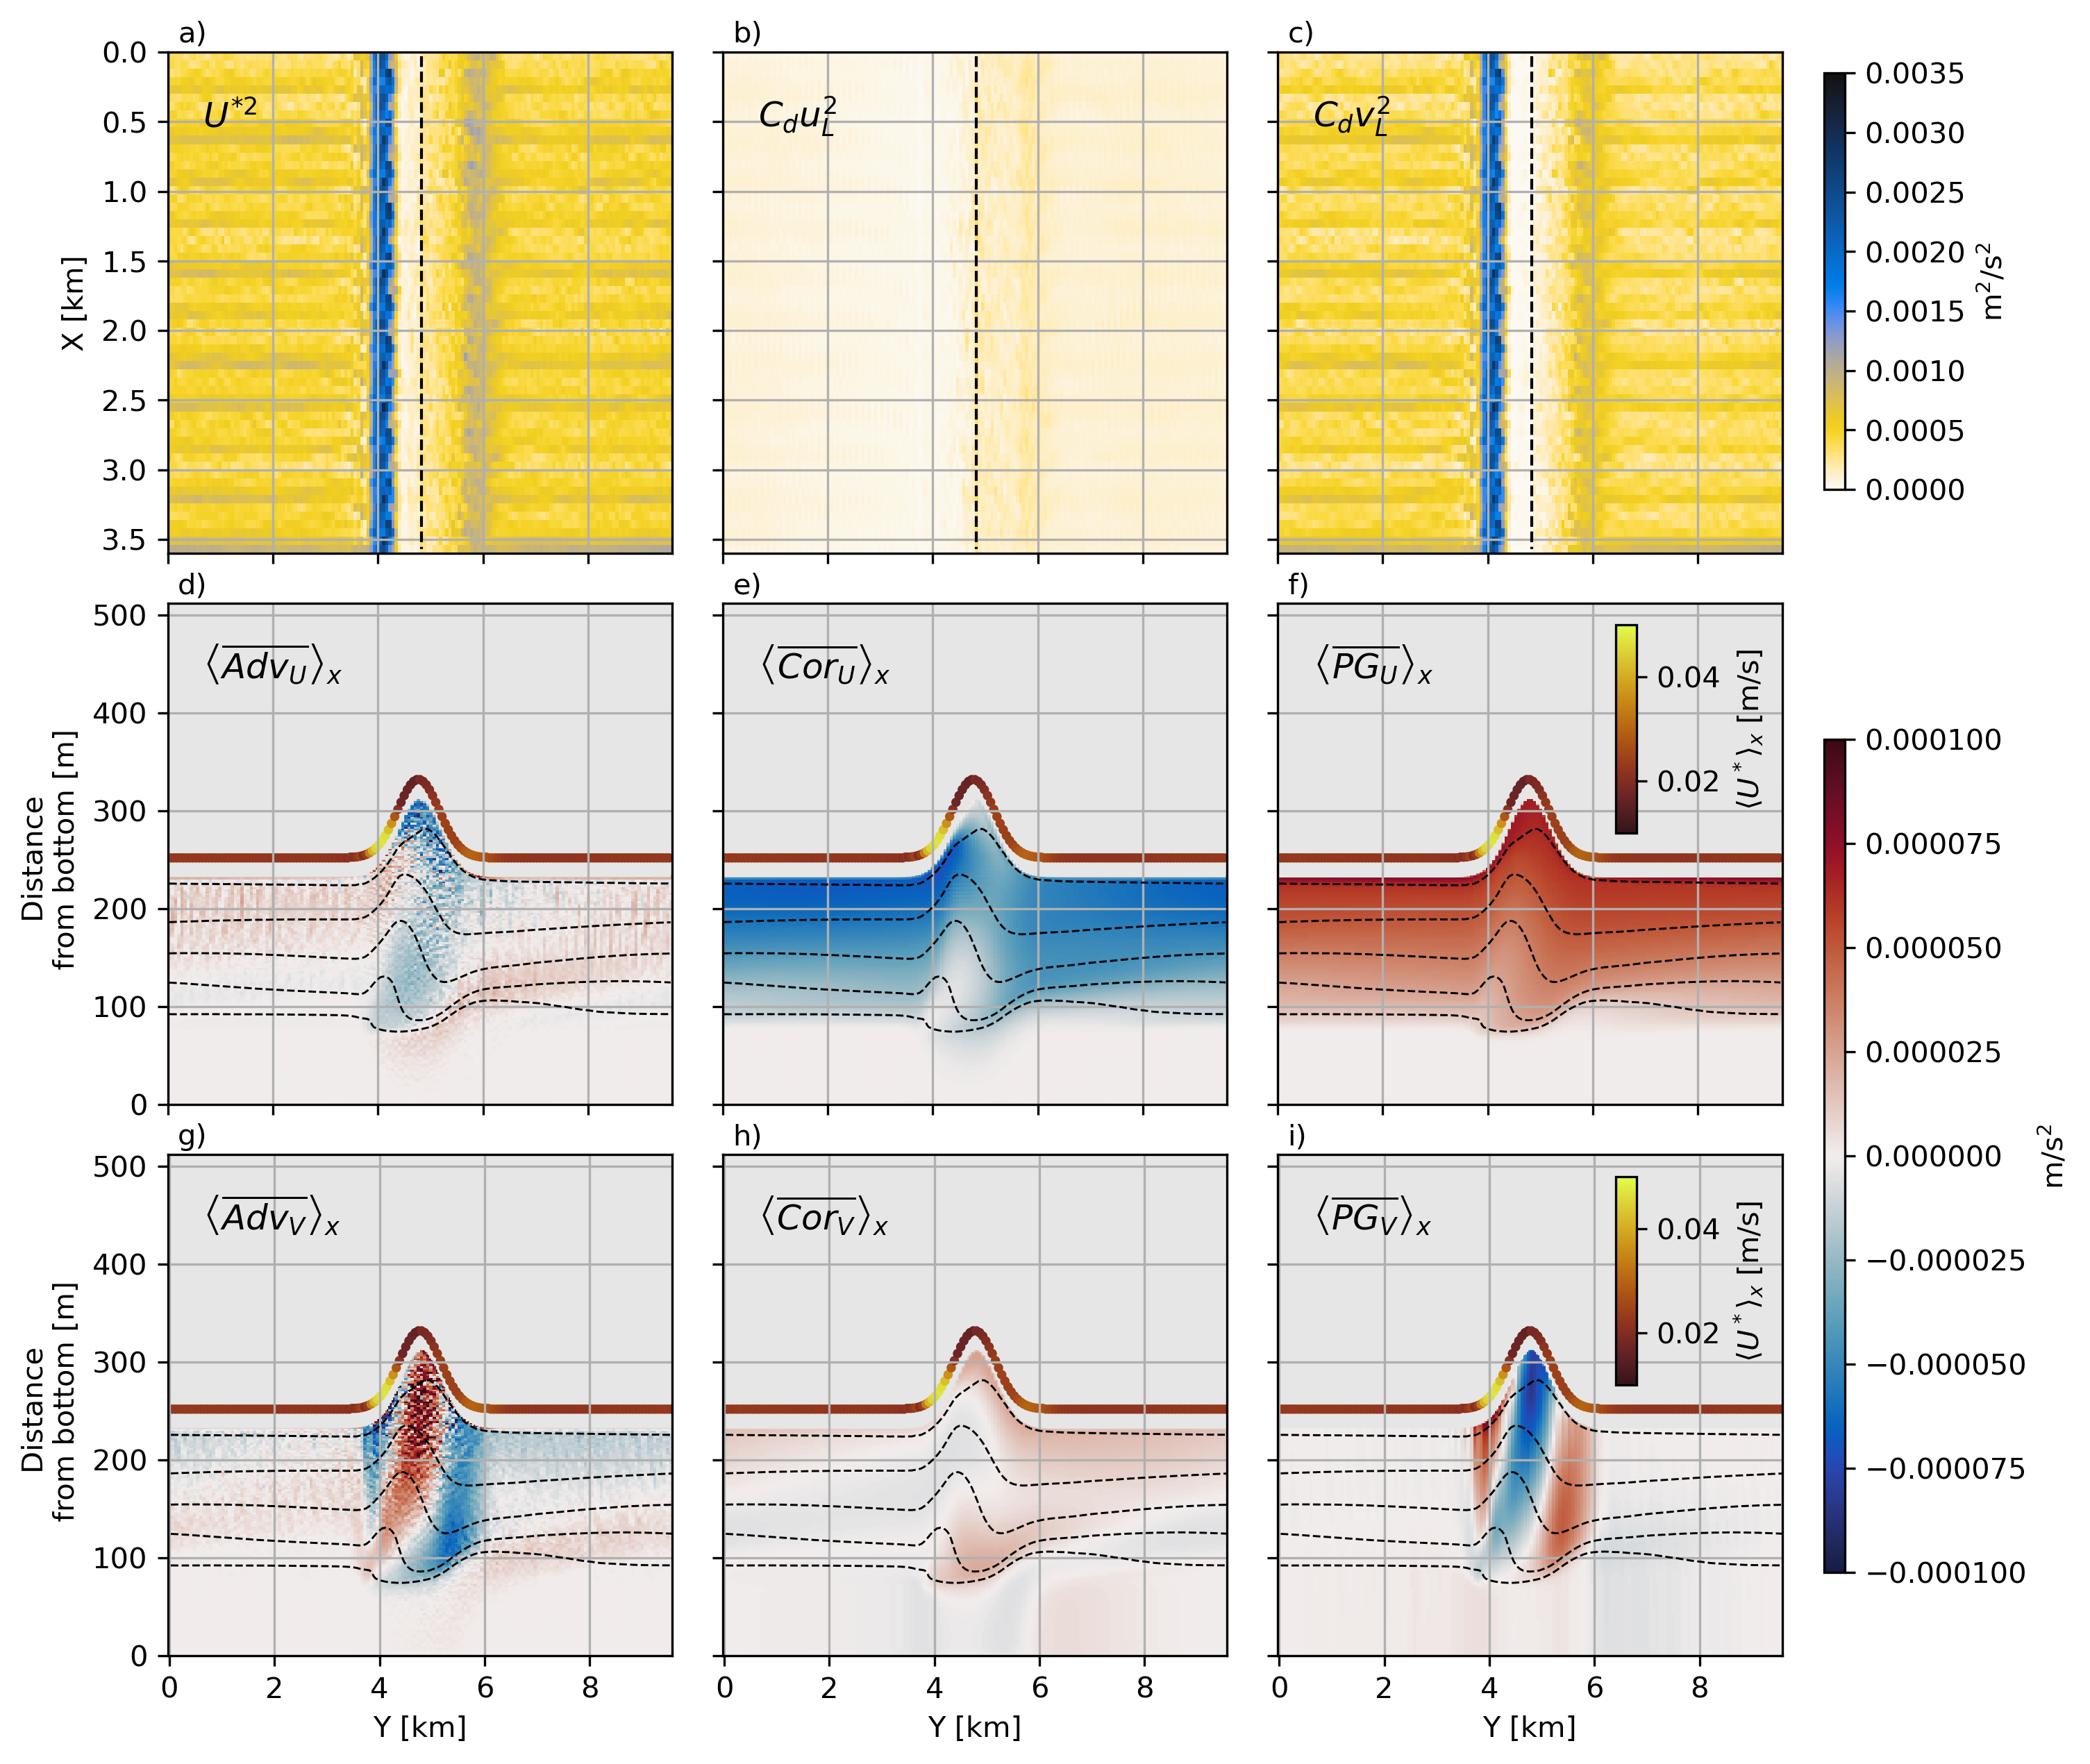

In [22]:
fig, ax =plt.subplots(3,3,figsize=(10,10),dpi=300)

kwargs={ 
    "cmap":ccm.cm.CET_CBL2_r,
    "vmin":0,
    "vmax":0.0035,
    "add_colorbar":False,
    "rasterized":True
}


cbar1 = (Ustar2).isel(time=-1).MAGVEL_c80m_Td2_vshift48_dz2.plot(x="YC",ax=ax[0,0],**kwargs)

(U**2 * Cd).isel(time=-1).SHIuBdly_c80m_Td2_vshift48_dz2.plot(x="YC",ax=ax[0,1],**kwargs)
(V**2 * Cd).isel(time=-1).SHIvBdly_c80m_Td2_vshift48_dz2.plot(x="YC",ax=ax[0,2],**kwargs)

ax[0,0].plot(np.ones_like(Ustar2.XC)*Ustar2.YC[80].values,Ustar2.XC,linestyle='--',color='k',linewidth=1)
ax[0,1].plot(np.ones_like(Ustar2.XC)*Ustar2.YC[80].values,Ustar2.XC,linestyle='--',color='k',linewidth=1)
ax[0,2].plot(np.ones_like(Ustar2.XC)*Ustar2.YC[80].values,Ustar2.XC,linestyle='--',color='k',linewidth=1)

kwargs={ 
    "cmap":cm.cm.balance,
    "vmin":-1.0e-4,
    "vmax":1.0e-4,
    "add_colorbar":False,
    "rasterized":True
}

kwargs_ustar={ 
    "cmap":cm.cm.solar,
    "vmin":0.01,
    "vmax":0.05,
}

True_advec_U = Um_Advec.Um_Advec_c80m_Td2_vshift48_dz2 - Um_Cori.Um_Cori_c80m_Td2_vshift48_dz2

cbar2 = True_advec_U.mean(("time","XG")).plot(x="YC",ax=ax[1,0],**kwargs)

Um_Cori.Um_Cori_c80m_Td2_vshift48_dz2.mean(("time","XG")).plot(x="YC",ax=ax[1,1],**kwargs)

Um_dPhiX.Um_dPhiX_c80m_Td2_vshift48_dz2.mean(("time","XG")).plot(x="YC",ax=ax[1,2],**kwargs)


plot_hfacc_surf_shifted(ax[1,0],
                                Um_Advec["hFacW_c80m_Td2_vshift48_dz2"].to_dataset(name="hFacC").rename({"XG":"XC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[1,1],
                                Um_Advec["hFacW_c80m_Td2_vshift48_dz2"].to_dataset(name="hFacC").rename({"XG":"XC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[1,2],
                                Um_Advec["hFacW_c80m_Td2_vshift48_dz2"].to_dataset(name="hFacC").rename({"XG":"XC","Z_dz2":"Z"}),
                                2,z_shift=-512)


cbar_us = plot_channel_surface_property(ax[1,0], z-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[1,1], z-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[1,2], z-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)

rhoA.RHOAnoma_c80m_Td2_vshift48_dz2.isel(time=-61).plot.contour(ax=ax[1,0],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA.RHOAnoma_c80m_Td2_vshift48_dz2.isel(time=-61).plot.contour(ax=ax[1,1],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA.RHOAnoma_c80m_Td2_vshift48_dz2.isel(time=-61).plot.contour(ax=ax[1,2],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

True_advec_V = Vm_Advec.Vm_Advec_c80m_Td2_vshift48_dz2 - Vm_Cori.Vm_Cori_c80m_Td2_vshift48_dz2

True_advec_V.mean(("time","XC")).plot(x="YG",ax=ax[2,0],**kwargs)

Vm_Cori.Vm_Cori_c80m_Td2_vshift48_dz2.mean(("time","XC")).plot(x="YG",ax=ax[2,1],**kwargs)

Vm_dPhiY.Vm_dPhiY_c80m_Td2_vshift48_dz2.mean(("time","XC")).plot(x="YG",ax=ax[2,2],**kwargs)

plot_hfacc_surf_shifted(ax[2,0],
                                Um_Advec["hFacW_c80m_Td2_vshift48_dz2"].to_dataset(name="hFacC").rename({"XG":"XC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[2,1],
                                Um_Advec["hFacW_c80m_Td2_vshift48_dz2"].to_dataset(name="hFacC").rename({"XG":"XC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[2,2],
                                Um_Advec["hFacW_c80m_Td2_vshift48_dz2"].to_dataset(name="hFacC").rename({"XG":"XC","Z_dz2":"Z"}),
                                2,z_shift=-512)

plot_channel_surface_property(ax[2,0], z-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[2,1], z-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[2,2], z-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)

rhoA.RHOAnoma_c80m_Td2_vshift48_dz2.isel(time=-61).plot.contour(ax=ax[2,0],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA.RHOAnoma_c80m_Td2_vshift48_dz2.isel(time=-61).plot.contour(ax=ax[2,1],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))
rhoA.RHOAnoma_c80m_Td2_vshift48_dz2.isel(time=-61).plot.contour(ax=ax[2,2],x="YC",vmin=-0.5,vmax=-0,add_colorbar=False,colors="k",linewidths=0.7,levels=np.arange(-0.25,-0,0.05))

cbar_ax = fig.add_axes([0.92, 0.67, 0.01, 0.2])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\mathrm{m}^2/\mathrm{s}^2$")
cbar_ax.yaxis.set_tick_params(labelsize=10)

cbar_ax = fig.add_axes([0.82, 0.505, 0.01, 0.1])
fig.colorbar(cbar_us, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<U^*\right>_x$ [m/s]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.4])
fig.colorbar(cbar2, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\mathrm{m/s}^2$")
cbar_ax.yaxis.set_tick_params(labelsize=10)

cbar_ax = fig.add_axes([0.82, 0.24, 0.01, 0.1])
fig.colorbar(cbar_us, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<U^*\right>_x$ [m/s]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.grid() for a in ax.ravel()]

ax[0,0].set_ylabel("X [km]")
[a.set_title("") for a in ax[:,:].ravel()]

[a.set_ylabel("Distance \n from bottom [m]") for a in ax[1:,0]]
[a.set_xlabel("Y [km]") for a in ax[2,:]]


ax[0,0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0,0].transAxes)
ax[0,1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[0,1].transAxes)
ax[0,2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[0,2].transAxes)
ax[1,0].text(0.02, 1.02, "d)", fontsize=10, transform=ax[1,0].transAxes)
ax[1,1].text(0.02, 1.02, "e)", fontsize=10, transform=ax[1,1].transAxes)
ax[1,2].text(0.02, 1.02, "f)", fontsize=10, transform=ax[1,2].transAxes)
ax[2,0].text(0.02, 1.02, "g)", fontsize=10, transform=ax[2,0].transAxes)
ax[2,1].text(0.02, 1.02, "h)", fontsize=10, transform=ax[2,1].transAxes)
ax[2,2].text(0.02, 1.02, "i)", fontsize=10, transform=ax[2,2].transAxes)

ticklocations = [-512,-412,-312,-212,-112,-12]
[a.yaxis.set_ticks(ticklocations) for a in ax[1:,:].ravel()]
ticklabels = [0,100,200,300,400,500]
[a.set_yticklabels(ticklabels) for a in ax[1:,:].ravel()]

[a.yaxis.set_ticklabels([]) for a in ax[0,1:]]
[a.xaxis.set_ticklabels([]) for a in ax[:-1,:].ravel()]
[a.yaxis.set_ticklabels([]) for a in ax[1:,1:].ravel()]
# [a.yaxis.set_ticklabels([]) for a in ax[1,1:]]

ax[0,0].text(0.07, 0.85, r"$U^{*2}$", fontsize=12, transform=ax[0,0].transAxes)
ax[0,1].text(0.07, 0.85, r"$C_du_{L}^{2}$", fontsize=12, transform=ax[0,1].transAxes)
ax[0,2].text(0.07, 0.85, r"$C_dv_{L}^{2}$", fontsize=12, transform=ax[0,2].transAxes)
ax[1,0].text(0.07, 0.85, r"$\left<\overline{Adv_U}\right>_x$", fontsize=12, transform=ax[1,0].transAxes)
ax[1,1].text(0.07, 0.85, r"$\left<\overline{Cor_U}\right>_x$", fontsize=12, transform=ax[1,1].transAxes)
ax[1,2].text(0.07, 0.85, r"$\left<\overline{PG_U}\right>_x$", fontsize=12, transform=ax[1,2].transAxes)
ax[2,0].text(0.07, 0.85, r"$\left<\overline{Adv_V}\right>_x$", fontsize=12, transform=ax[2,0].transAxes)
ax[2,1].text(0.07, 0.85, r"$\left<\overline{Cor_V}\right>_x$", fontsize=12, transform=ax[2,1].transAxes)
ax[2,2].text(0.07, 0.85, r"$\left<\overline{PG_V}\right>_x$", fontsize=12, transform=ax[2,2].transAxes)

[a.invert_yaxis() for a in ax[0,:]]

plt.subplots_adjust(wspace=0.1, hspace=0.1)


plt.savefig('./figures/Fig_6_ustar_momentum.pdf'.format(c), dpi=300, bbox_inches='tight')
